In [1]:
# Cell 1 — Load and validate all PPS result files.
from __future__ import annotations

import os
import re
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ntsa-pps")

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import font_manager
from scipy import stats


def locate_phase1(start: Path) -> Path:
    """Locate the phase1 directory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if candidate.name == "phase1" and (candidate / "results").is_dir():
            return candidate
        if (candidate / "phase1" / "results").is_dir():
            return candidate / "phase1"
    raise FileNotFoundError("Could not locate phase1.")


PHASE1_DIR = locate_phase1(Path.cwd())
INPUT_DIR = PHASE1_DIR / "results" / "statistic" / "processed"
OUTPUT_DIR = PHASE1_DIR / "outputs" / "statistic"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PRIMARY_METRICS = ("CC", "NRMSE", "DET", "Lmean", "LAM", "TT")
ALL_METRICS = PRIMARY_METRICS + ("ENTR", "Lmax", "Vmax")
STATES = ("Awake", "Drowsy")
KEYS = ["session", "representation", "state", "window_size", "window_id"]
EXPECTED_SESSIONS, EXPECTED_SURROGATES, ALPHA = 20, 39, 0.05
PATTERN = re.compile(r"session_(\d+)_processed_pps_(surrogate|window)_results\.csv")
REPORT_PATH = OUTPUT_DIR / "rq1_pps_integrity_report.csv"
integrity_rows = []


def require(name: str, condition: bool, details: str) -> None:
    """Record a check and fail loudly when it does not pass."""
    integrity_rows.append(
        {"check": name, "passed": bool(condition), "details": details}
    )
    if not condition:
        pd.DataFrame(integrity_rows).to_csv(REPORT_PATH, index=False)
        raise AssertionError(f"{name}: {details}")


file_map = {"window": {}, "surrogate": {}}
for path in sorted(INPUT_DIR.glob("session_*_processed_pps_*_results.csv")):
    match = PATTERN.fullmatch(path.name)
    if match:
        session_id, kind = int(match.group(1)), match.group(2)
        require(
            f"unique_{kind}_file_session_{session_id:02d}",
            session_id not in file_map[kind],
            path.name,
        )
        file_map[kind][session_id] = path
window_sessions, surrogate_sessions = map(set, file_map.values())
sessions = sorted(window_sessions | surrogate_sessions)
require("exactly_20_sessions", len(sessions) == 20, f"found={len(sessions)}")
require(
    "one_file_pair_per_session",
    window_sessions == surrogate_sessions,
    f"window_only={sorted(window_sessions - surrogate_sessions)}; "
    f"surrogate_only={sorted(surrogate_sessions - window_sessions)}",
)
require("exactly_40_files", sum(map(len, file_map.values())) == 40, "expected=40")


def read_results(kind: str) -> pd.DataFrame:
    """Read one result type and verify its session identifiers."""
    frames = []
    for session_id in sessions:
        path = file_map[kind][session_id]
        frame = pd.read_csv(path)
        require(
            f"filename_session_matches_{kind}_{session_id:02d}",
            set(frame["session"].astype(int)) == {session_id},
            path.name,
        )
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)


window_all, surrogate_all = read_results("window"), read_results("surrogate")
window_results = window_all.loc[
    window_all["representation"].eq("Processed")
    & window_all["window_size"].eq(60)
    & window_all["state"].isin(STATES)
].copy()
surrogate_results = surrogate_all.loc[
    surrogate_all["representation"].eq("Processed")
    & surrogate_all["window_size"].eq(60)
    & surrogate_all["state"].isin(STATES)
].copy()
require(
    "all_sessions_in_primary_subset",
    set(window_results["session"].astype(int)) == set(sessions),
    f"found={window_results['session'].nunique()}",
)
for state in STATES:
    count = window_results.loc[window_results["state"].eq(state), "session"].nunique()
    require(f"20_sessions_in_{state.lower()}", count == 20, f"found={count}")

window_keys = pd.MultiIndex.from_frame(window_results[KEYS])
surrogate_keys = pd.MultiIndex.from_frame(surrogate_results[KEYS].drop_duplicates())
require("unique_original_window_keys", not window_keys.has_duplicates, "one row/window")
require(
    "original_surrogate_window_keys_match",
    set(window_keys) == set(surrogate_keys),
    f"original={len(set(window_keys))}; surrogate={len(set(surrogate_keys))}",
)
duplicates = surrogate_results.duplicated(KEYS + ["surrogate_id"])
require("no_duplicate_surrogate_rows", not duplicates.any(), f"n={duplicates.sum()}")
groups = surrogate_results.groupby(KEYS, sort=True)
counts = groups.size()
require(
    "exactly_39_surrogates_per_window",
    counts.eq(39).all(),
    f"range={counts.min()}-{counts.max()}",
)
id_counts = groups["surrogate_id"].nunique()
require(
    "unique_surrogate_ids_within_window",
    id_counts.eq(39).all(),
    f"range={id_counts.min()}-{id_counts.max()}",
)
frozen = {
    "M": 39, "m": 8, "tau_seconds": 0.16, "n_horizons": 18,
    "hmax_seconds": 4.0, "theiler_seconds": 1.0,
}
for column, expected in frozen.items():
    observed = window_results[column].to_numpy(dtype=float)
    require(
        f"frozen_{column}",
        np.allclose(observed, expected, rtol=0.0, atol=1e-12),
        f"expected={expected}; unique={sorted(pd.unique(observed))}",
    )
surrogate_matrix = surrogate_results[list(ALL_METRICS)].to_numpy(dtype=float)
original_columns = [f"{metric}_original" for metric in ALL_METRICS]
original_matrix = window_results[original_columns].to_numpy(dtype=float)
require(
    "finite_surrogate_metrics",
    np.isfinite(surrogate_matrix).all(),
    "all 9 metrics",
)
require("finite_original_metrics", np.isfinite(original_matrix).all(), "valid rows")

indexed = window_results.set_index(KEYS).sort_index()
for metric in ALL_METRICS:
    metric_groups = groups[metric]
    original = indexed[f"{metric}_original"].sort_index()
    mean = metric_groups.mean().sort_index()
    sd = metric_groups.std(ddof=1).sort_index()
    median = metric_groups.median().sort_index()

    def compare(values: pd.Series, operator) -> int:
        """Count surrogate comparisons with the matched original."""
        return np.count_nonzero(
            operator(values.to_numpy(), original.loc[values.name])
        )

    n_less = metric_groups.apply(
        lambda values: compare(values, np.less)
    ).sort_index()
    n_equal = metric_groups.apply(
        lambda values: compare(values, np.equal)
    ).sort_index()
    n_lower = metric_groups.apply(
        lambda values: compare(values, np.less_equal)
    ).sort_index()
    n_upper = metric_groups.apply(
        lambda values: compare(values, np.greater_equal)
    ).sort_index()
    rank = 1.0 + n_less + 0.5 * n_equal
    p_upper = (n_upper + 1.0) / 40.0
    p_lower = (n_lower + 1.0) / 40.0
    p_value = np.minimum(1.0, 2.0 * np.minimum(p_upper, p_lower))
    reject = p_value <= ALPHA
    direction = pd.Series("none", index=p_value.index, dtype=object)
    direction.loc[reject & p_upper.lt(p_lower)] = "higher"
    direction.loc[reject & p_lower.lt(p_upper)] = "lower"
    for suffix, recomputed in {
        "surrogate_mean": mean, "surrogate_sd": sd,
        "surrogate_median": median, "rank": rank, "p": p_value,
    }.items():
        saved = indexed[f"{metric}_{suffix}"].sort_index().astype(float)
        difference = np.abs(recomputed.to_numpy() - saved.to_numpy())
        require(
            f"recomputed_{metric}_{suffix}_matches",
            np.allclose(recomputed, saved, rtol=1e-12, atol=1e-12),
            f"max_abs_difference={difference.max():.3g}",
        )
    saved_reject = indexed[f"{metric}_reject"].sort_index().astype(bool)
    saved_direction = indexed[f"{metric}_direction"].sort_index().astype(str)
    require(
        f"recomputed_{metric}_reject_matches", reject.equals(saved_reject),
        f"mismatches={(reject != saved_reject).sum()}",
    )
    require(
        f"recomputed_{metric}_direction_matches",
        np.array_equal(direction.to_numpy(), saved_direction.to_numpy()),
        f"mismatches={(direction != saved_direction).sum()}",
    )

integrity_report = pd.DataFrame(integrity_rows)
integrity_report.to_csv(REPORT_PATH, index=False)
print(
    f"PPS audit PASSED | 40 files | 20 sessions | {len(window_results)} windows | "
    f"{len(surrogate_results)} surrogate rows | {len(integrity_report)} checks"
)
display(integrity_report.tail(12))


PPS audit PASSED | 40 files | 20 sessions | 901 windows | 35139 surrogate rows | 162 checks


,check,passed,details
150,recomputed_Lmax_surrogate_median_matches,True,max_abs_difference=0
151,recomputed_Lmax_rank_matches,True,max_abs_difference=0
152,recomputed_Lmax_p_matches,True,max_abs_difference=0
153,recomputed_Lmax_reject_matches,True,mismatches=0
154,recomputed_Lmax_direction_matches,True,mismatches=0
155,recomputed_Vmax_surrogate_mean_matches,True,max_abs_difference=7.11e-15
156,recomputed_Vmax_surrogate_sd_matches,True,max_abs_difference=3.55e-15
157,recomputed_Vmax_surrogate_median_matches,True,max_abs_difference=0
158,recomputed_Vmax_rank_matches,True,max_abs_difference=0
159,recomputed_Vmax_p_matches,True,max_abs_difference=0


In [2]:
# Cell 2 — Construct window-to-session PPS effect summaries.
quantiles = surrogate_results.groupby(KEYS, sort=True)[
    list(PRIMARY_METRICS)
].quantile([0.25, 0.75]).unstack(level=-1)
effect_frames = []
for metric in PRIMARY_METRICS:
    frame = window_results[KEYS].copy()
    frame["metric"] = metric
    frame["original"] = window_results[f"{metric}_original"]
    for name in ("mean", "sd", "median"):
        frame[f"surrogate_{name}"] = window_results[f"{metric}_surrogate_{name}"]
    key_index = pd.MultiIndex.from_frame(frame[KEYS])
    q25 = quantiles[(metric, 0.25)].reindex(key_index).to_numpy()
    q75 = quantiles[(metric, 0.75)].reindex(key_index).to_numpy()
    frame["surrogate_iqr"] = q75 - q25
    frame["finite_sample_p"] = window_results[f"{metric}_p"]
    frame["reject"] = window_results[f"{metric}_reject"].astype(bool)
    frame["direction"] = window_results[f"{metric}_direction"]
    frame["delta_pps"] = frame["original"] - frame["surrogate_median"]
    effect_frames.append(frame)
window_effects = pd.concat(effect_frames, ignore_index=True)
session_state_summary = (
    window_effects.groupby(["session", "state", "metric"], sort=True)
    .agg(
        median_delta_pps=("delta_pps", "median"),
        median_surrogate_iqr=("surrogate_iqr", "median"),
        median_surrogate_sd=("surrogate_sd", "median"),
        rejection_fraction=("reject", "mean"),
        fraction_delta_positive=("delta_pps", lambda x: np.mean(x > 0.0)),
        fraction_delta_negative=("delta_pps", lambda x: np.mean(x < 0.0)),
        fraction_delta_zero=("delta_pps", lambda x: np.mean(x == 0.0)),
        n_valid_windows=("delta_pps", "size"),
    ).reset_index()
)
expected_rows = EXPECTED_SESSIONS * len(STATES) * len(PRIMARY_METRICS)
if len(session_state_summary) != expected_rows:
    raise AssertionError(
        f"Expected {expected_rows} summary rows; "
        f"found {len(session_state_summary)}."
    )
if session_state_summary.duplicated(["session", "state", "metric"]).any():
    raise AssertionError("Session-state-metric rows are not unique.")
direction_sum = session_state_summary[[
    "fraction_delta_positive", "fraction_delta_negative", "fraction_delta_zero"
]].sum(axis=1)
if not np.allclose(direction_sum, 1.0):
    raise AssertionError("Delta direction fractions do not sum to one.")
summary_path = OUTPUT_DIR / "rq1_pps_session_state_summary_60s.csv"
session_state_summary.to_csv(summary_path, index=False)
print(
    f"Saved {len(session_state_summary)} session-state-metric rows to "
    f"{summary_path.name}."
)
display(session_state_summary.head(12))


Saved 240 session-state-metric rows to rq1_pps_session_state_summary_60s.csv.


,session,state,metric,median_delta_pps,median_surrogate_iqr,median_surrogate_sd,rejection_fraction,fraction_delta_positive,fraction_delta_negative,fraction_delta_zero,n_valid_windows
0,1,Awake,CC,0.127940,0.062530,0.044338,0.541667,0.958333,0.041667,0.0,24
1,1,Awake,DET,0.099524,0.013103,0.009922,1.000000,1.000000,0.000000,0.0,24
2,1,Awake,LAM,-0.093092,0.018632,0.015250,0.750000,0.041667,0.958333,0.0,24
3,1,Awake,Lmean,1.407682,0.096068,0.075204,1.000000,1.000000,0.000000,0.0,24
4,1,Awake,NRMSE,-0.177911,0.039280,0.030948,0.958333,0.000000,1.000000,0.0,24
5,1,Awake,TT,-0.374783,0.091102,0.063954,1.000000,0.000000,1.000000,0.0,24
6,1,Drowsy,CC,0.133683,0.063296,0.045796,0.714286,1.000000,0.000000,0.0,7
7,1,Drowsy,DET,0.105353,0.012983,0.010457,1.000000,1.000000,0.000000,0.0,7
8,1,Drowsy,LAM,-0.046320,0.016332,0.011764,0.857143,0.142857,0.857143,0.0,7
9,1,Drowsy,Lmean,1.703883,0.118496,0.084545,1.000000,1.000000,0.000000,0.0,7


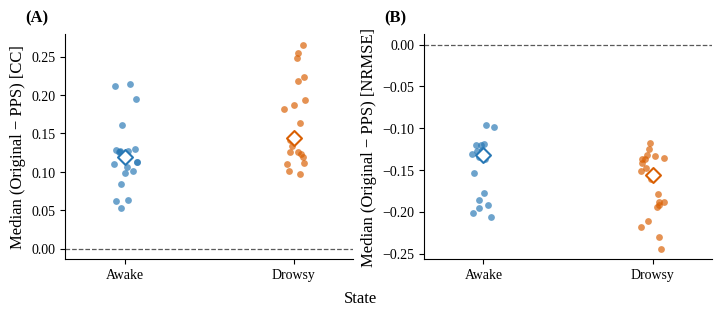

Saved rq1_pps_prediction_60s.pdf, rq1_pps_prediction_60s.svg, and rq1_pps_prediction_60s.png using Liberation Serif.


In [3]:
# Cell 3 — Publication figure: Prediction departure from PPS.
def select_serif_font() -> str:
    """Select Times New Roman or the approved serif fallback."""
    available = {font.name for font in font_manager.fontManager.ttflist}
    for family in ("Times New Roman", "Liberation Serif", "DejaVu Serif"):
        if family in available:
            return family
    return "serif"


PLOT_FONT = select_serif_font()
mpl.rcParams.update({
    "font.family": PLOT_FONT, "font.size": 11, "axes.labelsize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
})
STATE_COLORS = {"Awake": "#2878B5", "Drowsy": "#D95F02"}


def plot_departure(axis: plt.Axes, metric: str, panel: str) -> None:
    """Plot one session-level PPS departure panel."""
    metric_data = session_state_summary.loc[session_state_summary["metric"].eq(metric)]
    for state_index, state in enumerate(STATES):
        state_data = metric_data.loc[
            metric_data["state"].eq(state)
        ].sort_values("session")
        if len(state_data) != EXPECTED_SESSIONS:
            raise AssertionError(f"{metric}/{state} does not contain 20 sessions.")
        jitter_seed = (
            20260831 + 100 * state_index + PRIMARY_METRICS.index(metric)
        )
        rng = np.random.default_rng(jitter_seed)
        jitter = rng.uniform(-0.075, 0.075, len(state_data))
        values = state_data["median_delta_pps"].to_numpy(dtype=float)
        axis.scatter(
            state_index + jitter, values, s=24, color=STATE_COLORS[state],
            alpha=0.68, linewidths=0.0, zorder=2,
        )
        axis.scatter(
            state_index, np.median(values), marker="D", s=58, facecolors="white",
            edgecolors=STATE_COLORS[state], linewidths=1.5, zorder=3,
        )
    axis.axhline(0.0, color="0.35", linewidth=0.9, linestyle="--", zorder=1)
    axis.set_xticks([0, 1], STATES)
    axis.set_xlim(-0.35, 1.35)
    axis.set_ylabel(f"Median (Original − PPS) [{metric}]")
    axis.text(
        -0.14, 1.04, panel, transform=axis.transAxes, fontsize=12,
        fontweight="bold", va="bottom", ha="left",
    )


fig, axes = plt.subplots(1, 2, figsize=(7.10, 3.05), constrained_layout=True)
for axis, metric, panel in zip(axes, ("CC", "NRMSE"), ("(A)", "(B)")):
    plot_departure(axis, metric, panel)
fig.supxlabel("State", fontsize=12)
prediction_pdf = OUTPUT_DIR / "rq1_pps_prediction_60s.pdf"
prediction_svg = OUTPUT_DIR / "rq1_pps_prediction_60s.svg"
prediction_png = OUTPUT_DIR / "rq1_pps_prediction_60s.png"
fig.savefig(prediction_pdf, bbox_inches="tight")
fig.savefig(prediction_svg, bbox_inches="tight")
fig.savefig(prediction_png, dpi=600, bbox_inches="tight")
plt.show()
print(
    f"Saved {prediction_pdf.name}, {prediction_svg.name}, and "
    f"{prediction_png.name} using {PLOT_FONT}."
)


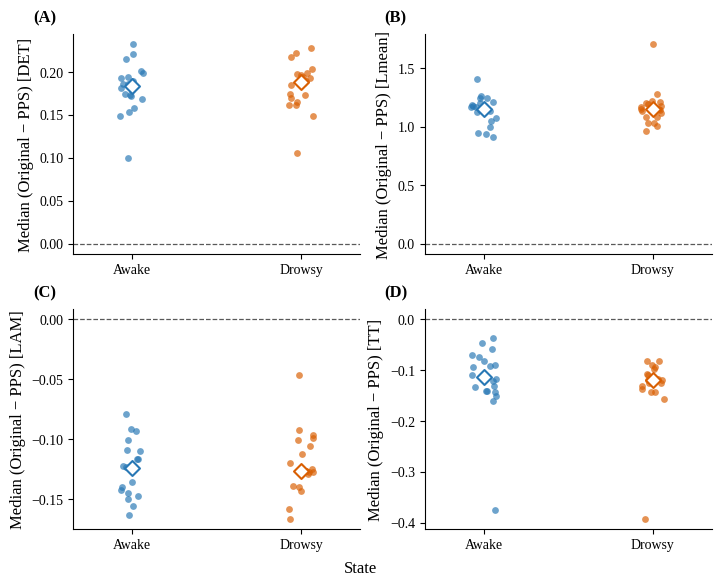

Saved rq1_pps_rqa_60s.pdf, rq1_pps_rqa_60s.svg, and rq1_pps_rqa_60s.png using Liberation Serif.


In [4]:
# Cell 4 — Publication figure: Recurrence structure departure from PPS.
fig, axes = plt.subplots(2, 2, figsize=(7.10, 5.75), constrained_layout=True)
for axis, metric, panel in zip(
    axes.ravel(), ("DET", "Lmean", "LAM", "TT"),
    ("(A)", "(B)", "(C)", "(D)"),
):
    plot_departure(axis, metric, panel)
fig.supxlabel("State", fontsize=12)
rqa_pdf = OUTPUT_DIR / "rq1_pps_rqa_60s.pdf"
rqa_svg = OUTPUT_DIR / "rq1_pps_rqa_60s.svg"
rqa_png = OUTPUT_DIR / "rq1_pps_rqa_60s.png"
fig.savefig(rqa_pdf, bbox_inches="tight")
fig.savefig(rqa_svg, bbox_inches="tight")
fig.savefig(rqa_png, dpi=600, bbox_inches="tight")
plt.show()
print(
    f"Saved {rqa_pdf.name}, {rqa_svg.name}, and {rqa_png.name} "
    f"using {PLOT_FONT}."
)


### Prediction vs PPS — Kết luận từ Median (Original − PPS)

Với mỗi window, độ lệch so với PPS được định nghĩa:

$$
\Delta_{\mathrm{PPS}}
=
X_{\mathrm{Original}}
-
\operatorname{median}(X_{\mathrm{PPS}})
$$

Sau đó, median của $\Delta_{\mathrm{PPS}}$ được tính trong từng `session × state` để mô tả mức lệch điển hình giữa tín hiệu gốc và PPS.

Kết quả cho thấy ở cả Awake và Drowsy:

- **CC:** `Median (Original − PPS) > 0`
- **NRMSE:** `Median (Original − PPS) < 0`

Do đó, Processed PPG gốc có xu hướng:

$$
CC_{\mathrm{Original}} > CC_{\mathrm{PPS}}
$$

và

$$
NRMSE_{\mathrm{Original}} < NRMSE_{\mathrm{PPS}}
$$

tức là **forecastability của tín hiệu gốc cao hơn rõ rệt so với matched PPS surrogates**.

Đáng chú ý, direction này được tái lập nhất quán qua các session ở cả hai trạng thái, cho thấy đây không phải hiệu ứng do một vài phiên riêng lẻ.

Các figure này mô tả **magnitude, direction và session-level consistency** của độ lệch Original–PPS; formal rejection của PPS null được đánh giá riêng bằng finite-sample rank testing và các bước statistical validation tiếp theo.

### Vì sao dùng median của 39 PPS thay vì mean?

Độ lệch được định nghĩa bằng:

$$
\Delta_{\mathrm{PPS}}
=
X_{\mathrm{Original}}
-
\operatorname{median}(X_{\mathrm{PPS}})
$$

thay vì:

$$
X_{\mathrm{Original}}
-
\operatorname{mean}(X_{\mathrm{PPS}})
$$

vì phân phối các surrogate statistics không nhất thiết đối xứng và có thể chứa các giá trị cực trị, đặc biệt với một số RQA metrics. Median đại diện tốt hơn cho **giá trị điển hình** của 39 PPS và ít bị ảnh hưởng bởi outlier hoặc skewness hơn mean.

Việc dùng median ở đây chỉ nhằm mô tả **effect magnitude và direction** một cách robust; formal surrogate inference vẫn dựa trên **finite-sample rank test**, không phụ thuộc vào việc chọn mean hay median làm giá trị tham chiếu mô tả.

In [5]:
# Cell 5 — Formal session-level inference against the PPS null.
BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED = 20_000, 20260831


def bootstrap_median_ci(values: np.ndarray, seed: int) -> tuple[float, float]:
    """Return a percentile bootstrap CI for the session median."""
    rng = np.random.default_rng(seed)
    indices = rng.integers(0, len(values), size=(BOOTSTRAP_RESAMPLES, len(values)))
    return tuple(np.percentile(np.median(values[indices], axis=1), [2.5, 97.5]))


def signed_rank_biserial(values: np.ndarray) -> float:
    """Return the signed-rank rank-biserial effect size."""
    nonzero = values[values != 0.0]
    if nonzero.size == 0:
        return 0.0
    ranks = stats.rankdata(np.abs(nonzero), method="average")
    positive, negative = ranks[nonzero > 0.0].sum(), ranks[nonzero < 0.0].sum()
    return float((positive - negative) / (positive + negative))


def benjamini_hochberg(p_values: np.ndarray) -> np.ndarray:
    """Adjust one p-value family with BH-FDR."""
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values, kind="stable")
    ordered = p_values[order]
    adjusted = ordered * len(ordered) / np.arange(1, len(ordered) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    result = np.empty_like(adjusted)
    result[order] = np.clip(adjusted, 0.0, 1.0)
    return result


domains = {
    "CC": "Prediction", "NRMSE": "Prediction",
    "DET": "Diagonal recurrence", "Lmean": "Diagonal recurrence",
    "LAM": "Laminar recurrence", "TT": "Laminar recurrence",
}
inference_rows = []
for test_index, (metric, state) in enumerate(
    (metric, state) for metric in PRIMARY_METRICS for state in STATES
):
    selected = session_state_summary.loc[
        session_state_summary["metric"].eq(metric)
        & session_state_summary["state"].eq(state)
    ].sort_values("session")
    values = selected["median_delta_pps"].to_numpy(dtype=float)
    if len(values) != 20 or not np.isfinite(values).all():
        raise AssertionError(f"Invalid session values for {metric}/{state}.")
    test_seed = BOOTSTRAP_SEED + test_index
    ci_low, ci_high = bootstrap_median_ci(values, test_seed)
    if np.all(values == 0.0):
        statistic, p_value = 0.0, 1.0
    else:
        test = stats.wilcoxon(
            values, zero_method="wilcox", correction=False,
            alternative="two-sided", method="auto",
        )
        statistic, p_value = float(test.statistic), float(test.pvalue)
    inference_rows.append({
        "domain": domains[metric], "metric": metric, "state": state,
        "n_sessions": len(values), "median_delta_pps": np.median(values),
        "ci95_low": ci_low, "ci95_high": ci_high,
        "bootstrap_resamples": BOOTSTRAP_RESAMPLES, "bootstrap_seed": test_seed,
        "wilcoxon_statistic": statistic, "raw_p_value": p_value,
        "rank_biserial_r_rb": signed_rank_biserial(values),
        "n_positive": np.count_nonzero(values > 0.0),
        "n_negative": np.count_nonzero(values < 0.0),
        "n_zero": np.count_nonzero(values == 0.0),
        "median_window_rejection_fraction": selected["rejection_fraction"].median(),
    })
primary_statistics = pd.DataFrame(inference_rows)
if len(primary_statistics) != 12:
    raise AssertionError("The BH-FDR family must contain exactly 12 tests.")
primary_statistics["q_BH"] = benjamini_hochberg(primary_statistics["raw_p_value"])
primary_statistics["BH_supported"] = primary_statistics["q_BH"].le(ALPHA)
primary_statistics["CI_excludes_zero"] = (
    primary_statistics["ci95_low"].gt(0.0) | primary_statistics["ci95_high"].lt(0.0)
)
statistics_path = OUTPUT_DIR / "rq1_pps_primary_statistics_60s.csv"
primary_statistics.to_csv(statistics_path, index=False)
print(f"Completed one 12-test BH-FDR family; saved {statistics_path.name}.")
display(primary_statistics[[
    "domain", "metric", "state", "median_delta_pps", "ci95_low",
    "ci95_high", "rank_biserial_r_rb", "raw_p_value", "q_BH", "BH_supported",
]])


Completed one 12-test BH-FDR family; saved rq1_pps_primary_statistics_60s.csv.


,domain,metric,state,median_delta_pps,ci95_low,ci95_high,rank_biserial_r_rb,raw_p_value,q_BH,BH_supported
0,Prediction,CC,Awake,0.119218,0.103444,0.127786,1.0,0.000002,0.000002,True
1,Prediction,CC,Drowsy,0.144092,0.124492,0.190643,1.0,0.000002,0.000002,True
2,Prediction,NRMSE,Awake,-0.132145,-0.165841,-0.127257,-1.0,0.000002,0.000002,True
3,Prediction,NRMSE,Drowsy,-0.155682,-0.190129,-0.137018,-1.0,0.000002,0.000002,True
4,Diagonal recurrence,DET,Awake,0.183256,0.172698,0.193862,1.0,0.000002,0.000002,True
5,Diagonal recurrence,DET,Drowsy,0.188463,0.171318,0.197089,1.0,0.000002,0.000002,True
6,Diagonal recurrence,Lmean,Awake,1.152778,1.094742,1.189112,1.0,0.000002,0.000002,True
7,Diagonal recurrence,Lmean,Drowsy,1.150790,1.102334,1.181452,1.0,0.000002,0.000002,True
8,Laminar recurrence,LAM,Awake,-0.124394,-0.141095,-0.112987,-1.0,0.000002,0.000002,True
9,Laminar recurrence,LAM,Drowsy,-0.126620,-0.128179,-0.109079,-1.0,0.000002,0.000002,True


In [6]:
# Cell 6 — Final evidence table and automatic RQ1 conclusion.
def classify_evidence(row: pd.Series) -> str:
    """Classify multiplicity-controlled and directional evidence."""
    if row["BH_supported"]:
        return "BH-FDR supported departure from PPS"
    majority = max(row["n_positive"], row["n_negative"]) > row["n_sessions"] / 2
    if row["CI_excludes_zero"] and majority:
        return "Directionally consistent but not BH-FDR supported"
    return "No clear systematic departure"


final_evidence = primary_statistics.copy()
final_evidence["session_direction"] = final_evidence.apply(
    lambda row: (
        f"{int(row['n_positive'])}/{int(row['n_sessions'])} positive; "
        f"{int(row['n_negative'])}/{int(row['n_sessions'])} negative; "
        f"{int(row['n_zero'])} zero"
    ), axis=1,
)
final_evidence["evidence_class"] = final_evidence.apply(classify_evidence, axis=1)
final_evidence["ci95"] = final_evidence.apply(
    lambda row: f"[{row['ci95_low']:.5f}, {row['ci95_high']:.5f}]", axis=1
)
evidence_path = OUTPUT_DIR / "rq1_pps_final_evidence_table_60s.csv"
final_evidence.to_csv(evidence_path, index=False)
compact_table = final_evidence[[
    "domain", "metric", "state", "median_delta_pps", "ci95",
    "rank_biserial_r_rb", "q_BH", "session_direction",
    "median_window_rejection_fraction", "evidence_class",
]].rename(columns={
    "domain": "Domain", "metric": "Metric", "state": "State",
    "median_delta_pps": "Median Delta_PPS", "ci95": "95% CI",
    "rank_biserial_r_rb": "r_rb", "q_BH": "q_BH",
    "session_direction": "Session direction",
    "median_window_rejection_fraction": "Median rejection fraction",
    "evidence_class": "Evidence class",
})


def metric_finding(metric: str) -> str:
    """Describe direction and state replication for one metric."""
    rows = final_evidence.loc[final_evidence["metric"].eq(metric)].set_index("state")
    supported = [state for state in STATES if rows.loc[state, "BH_supported"]]
    direction = {
        state: ("above" if rows.loc[state, "median_delta_pps"] > 0.0 else "below")
        for state in STATES
    }
    if len(supported) == 2 and len(set(direction.values())) == 1:
        return (f"- {metric}: original values were {direction['Awake']} the PPS median "
                "in both Awake and Drowsy after BH-FDR correction.")
    if len(supported) == 2:
        return (f"- {metric}: departures were BH-supported in both states "
                f"(Awake {direction['Awake']}; Drowsy {direction['Drowsy']} PPS).")
    if len(supported) == 1:
        state = supported[0]
        return (f"- {metric}: a BH-supported departure occurred in {state} only "
                f"(original {direction[state]} PPS).")
    directional = (
        rows["evidence_class"]
        == "Directionally consistent but not BH-FDR supported"
    ).any()
    if directional:
        return (
            f"- {metric}: directional evidence was present but lacked "
            "BH-FDR support."
        )
    return f"- {metric}: no clear systematic session-level departure was detected."


replication = {}
for metric in PRIMARY_METRICS:
    rows = final_evidence.loc[final_evidence["metric"].eq(metric)].set_index("state")
    key = (
        bool(rows.loc["Awake", "BH_supported"]),
        bool(rows.loc["Drowsy", "BH_supported"]),
    )
    replication.setdefault(key, []).append(metric)
both = replication.get((True, True), [])
replication_text = (
    "BH-supported departures replicated in both states for "
    f"{len(both)}/6 metrics"
)
if both:
    replication_text += f" ({', '.join(both)})"
replication_text += "."
replication_groups = [
    ((True, False), "Awake-only"),
    ((False, True), "Drowsy-only"),
    ((False, False), "No-state support"),
]
for key, label in replication_groups:
    if replication.get(key):
        replication_text += f" {label}: {', '.join(replication[key])}."

conclusion = "\n".join([
    "## RQ1 — PPS surrogate testing conclusion", "",
    "Across 20 independent sessions, original 60-s Processed PPG was compared with "
    "matched noisy pseudoperiodic surrogates using session-level summaries.", "",
    "### Prediction", metric_finding("CC"), metric_finding("NRMSE"), "",
    "### Diagonal recurrence organization", metric_finding("DET"),
    metric_finding("Lmean"), "",
    "### Laminar recurrence organization", metric_finding("LAM"),
    metric_finding("TT"), "",
    "### State replication", replication_text, "",
    "Collectively, supported deviations indicate that short-window Processed PPG "
    "contains dynamical organization not adequately captured by the tested noisy "
    "pseudoperiodic null model. Window rejection fractions are descriptive; formal "
    "inference uses one value per independent session and state.", "",
    "This result does **not** establish deterministic chaos or prove the existence "
    "of a strange attractor.",
])
conclusion_path = OUTPUT_DIR / "rq1_pps_conclusion_60s.md"
conclusion_path.write_text(conclusion + "\n", encoding="utf-8")
print(f"Saved {evidence_path.name} and {conclusion_path.name}.")
display(compact_table)
display(Markdown(conclusion))


Saved rq1_pps_final_evidence_table_60s.csv and rq1_pps_conclusion_60s.md.


,Domain,Metric,State,Median Delta_PPS,95% CI,r_rb,q_BH,Session direction,Median rejection fraction,Evidence class
0,Prediction,CC,Awake,0.119218,"[0.10344, 0.12779]",1.0,0.000002,20/20 positive; 0/20 negative; 0 zero,0.606602,BH-FDR supported departure from PPS
1,Prediction,CC,Drowsy,0.144092,"[0.12449, 0.19064]",1.0,0.000002,20/20 positive; 0/20 negative; 0 zero,0.710084,BH-FDR supported departure from PPS
2,Prediction,NRMSE,Awake,-0.132145,"[-0.16584, -0.12726]",-1.0,0.000002,0/20 positive; 20/20 negative; 0 zero,0.915899,BH-FDR supported departure from PPS
3,Prediction,NRMSE,Drowsy,-0.155682,"[-0.19013, -0.13702]",-1.0,0.000002,0/20 positive; 20/20 negative; 0 zero,1.000000,BH-FDR supported departure from PPS
4,Diagonal recurrence,DET,Awake,0.183256,"[0.17270, 0.19386]",1.0,0.000002,20/20 positive; 0/20 negative; 0 zero,1.000000,BH-FDR supported departure from PPS
5,Diagonal recurrence,DET,Drowsy,0.188463,"[0.17132, 0.19709]",1.0,0.000002,20/20 positive; 0/20 negative; 0 zero,1.000000,BH-FDR supported departure from PPS
6,Diagonal recurrence,Lmean,Awake,1.152778,"[1.09474, 1.18911]",1.0,0.000002,20/20 positive; 0/20 negative; 0 zero,1.000000,BH-FDR supported departure from PPS
7,Diagonal recurrence,Lmean,Drowsy,1.150790,"[1.10233, 1.18145]",1.0,0.000002,20/20 positive; 0/20 negative; 0 zero,1.000000,BH-FDR supported departure from PPS
8,Laminar recurrence,LAM,Awake,-0.124394,"[-0.14110, -0.11299]",-1.0,0.000002,0/20 positive; 20/20 negative; 0 zero,0.955000,BH-FDR supported departure from PPS
9,Laminar recurrence,LAM,Drowsy,-0.126620,"[-0.12818, -0.10908]",-1.0,0.000002,0/20 positive; 20/20 negative; 0 zero,0.923810,BH-FDR supported departure from PPS


## RQ1 — PPS surrogate testing conclusion

Across 20 independent sessions, original 60-s Processed PPG was compared with matched noisy pseudoperiodic surrogates using session-level summaries.

### Prediction
- CC: original values were above the PPS median in both Awake and Drowsy after BH-FDR correction.
- NRMSE: original values were below the PPS median in both Awake and Drowsy after BH-FDR correction.

### Diagonal recurrence organization
- DET: original values were above the PPS median in both Awake and Drowsy after BH-FDR correction.
- Lmean: original values were above the PPS median in both Awake and Drowsy after BH-FDR correction.

### Laminar recurrence organization
- LAM: original values were below the PPS median in both Awake and Drowsy after BH-FDR correction.
- TT: original values were below the PPS median in both Awake and Drowsy after BH-FDR correction.

### State replication
BH-supported departures replicated in both states for 6/6 metrics (CC, NRMSE, DET, Lmean, LAM, TT).

Collectively, supported deviations indicate that short-window Processed PPG contains dynamical organization not adequately captured by the tested noisy pseudoperiodic null model. Window rejection fractions are descriptive; formal inference uses one value per independent session and state.

This result does **not** establish deterministic chaos or prove the existence of a strange attractor.